# Taller 1 - clusterización con kmeans

Se tiene el conjunto de datos ```marketing_campaign.csv``` que contiene datos de 2240 clientes, de los cuales se cuenta con diferentes variables.

## Descripción del conjunto de variables
- AcceptedCmp1 - 1 if customer accepted the offer in the 1st campaign, 0 otherwise
- AcceptedCmp2 - 1 if customer accepted the offer in the 2nd campaign, 0 otherwise
- AcceptedCmp3 - 1 if customer accepted the offer in the 3rd campaign, 0 otherwise
- AcceptedCmp4 - 1 if customer accepted the offer in the 4th campaign, 0 otherwise
- AcceptedCmp5 - 1 if customer accepted the offer in the 5th campaign, 0 otherwise
- Response (target) - 1 if customer accepted the offer in the last campaign, 0 otherwise
- Complain - 1 if customer complained in the last 2 years
- DtCustomer - date of customer’s enrolment with the company
- Education - customer’s level of education
- Marital - customer’s marital status
- Kidhome - number of small children in customer’s household
- Teenhome - number of teenagers in customer’s household
- Income - customer’s yearly household income
- MntFishProducts - amount spent on fish products in the last 2 years
- MntMeatProducts - amount spent on meat products in the last 2 years
- MntFruits - amount spent on fruits products in the last 2 years
- MntSweetProducts - amount spent on sweet products in the last 2 years
- MntWines - amount spent on wine products in the last 2 years
- MntGoldProds - amount spent on gold products in the last 2 years
- NumDealsPurchases - number of purchases made with discount
- NumCatalogPurchases - number of purchases made using catalogue
- NumStorePurchases - number of purchases made directly in stores
- NumWebPurchases - number of purchases made through company’s web site
- NumWebVisitsMonth - number of visits to company’s web site in the last month
- Recency - number of days since the last purchase

## Objetivo

El departamento de mercadeo desea hacer una segmentación de los clientes, desea que se le presente un número limitado de grupos (clústers), el número de grupos lo determinará el analista y se espera que los grupos estén conformados de manera que los clientes tengan características de consumo lo más parecidas posibles.

El departamento de mercadeo sugiere que las variables más representativas para crear estos grupos son el gasto en dólares correspondiente a seis categorías: vino, frutas, carne, pescado, dulces y oro.

Pero el analista está en libertad de incluir las variables que considere pertinentes.

## Entregable


El analista debe:

- (30%) Presentar el modelo de clustering que utilizó (```código```)

- (10%) Informar el número de clusters que creo, justificando la razón de ello, con su respectivo análisis.

- (30%) Una vez haya creado los clusters, debe presentar una descripción de los clusters por las variables que considere relevantes (todas las variables disponibles en el dataset, no solo las variables del clustering).

- (30%) Informe ejecutivo con insights y recomendaciones pertinentes para el departamento de mercadeo, para su campaña de mercadeo sea lo más efectiva posible.


1. Importar librerias

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


2. Cargar base de datos

In [6]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Aprendizaje no supervisado/marketing_campaign.csv')

3. Visualizar los datos

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                    Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                                                                                                                                                                    --------------  ----- 
 0   ID	Year_Birth	Education	Marital_Status	Income	Kidhome	Teenhome	Dt_Customer	Recency	MntWines	M

In [7]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


4. Revisar si hay valores nulos

In [11]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


5.Eliminar los nulos

Como solo hay 24 valores nulos en la columna Income es mejor borrarlos ya que la base de datos tiene 2240 filas (clientes) para que no vayan a perjudicar despues el analisis y no es un numero muy significativo si se borrran

In [13]:
df.dropna(inplace=True)

6. Verificar si hay outliers

In [15]:
variables_numericas = df.select_dtypes(include=np.number).columns

print(variables_numericas)

Index(['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact',
       'Z_Revenue', 'Response'],
      dtype='object')


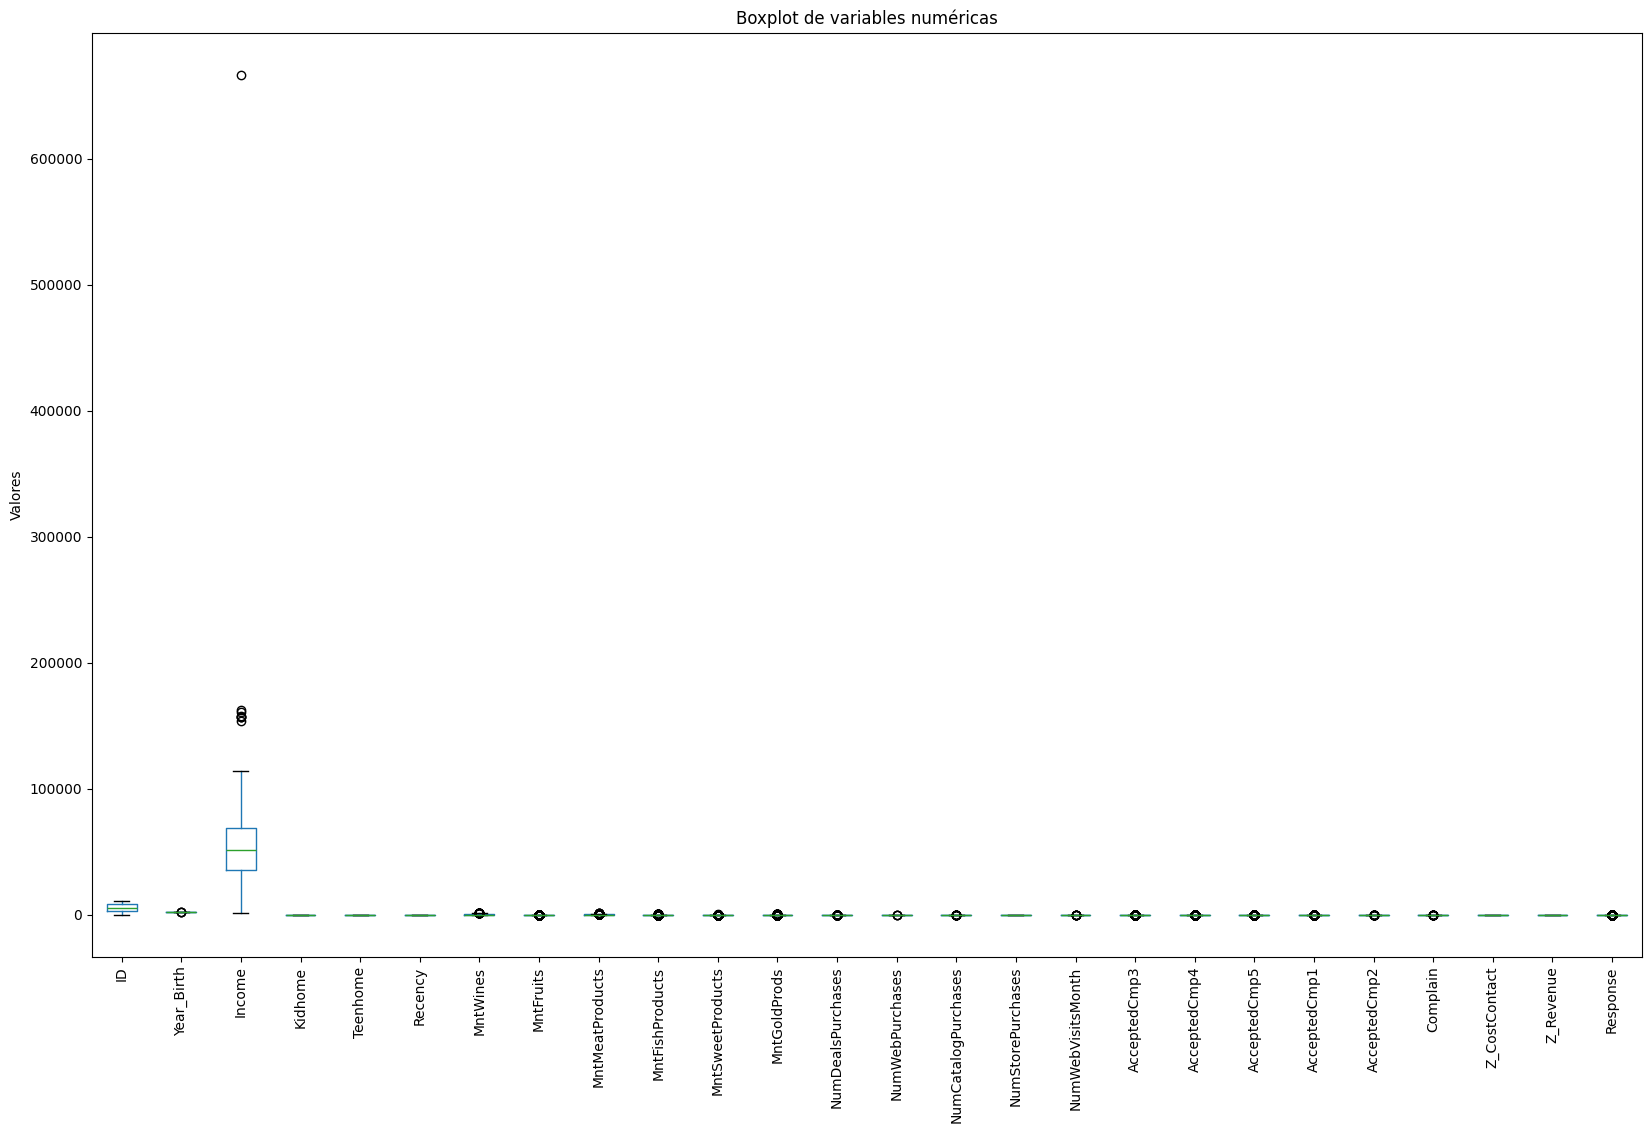

In [16]:
plt.figure(figsize=(20, 12))

df[variables_numericas].boxplot()

plt.title('Boxplot de variables numéricas')
plt.xticks(rotation=90)
plt.ylabel('Valores')
plt.grid(False)
plt.show()

En la grafica se puede visualizar que solo hay outliers en income

In [19]:
df['Income'].sort_values(ascending=False).head(10)

,Income
2233,666666.0
617,162397.0
687,160803.0
1300,157733.0
164,157243.0
1653,157146.0
2132,156924.0
655,153924.0
1898,113734.0
646,105471.0


El primer outlier es un valor sospechoso, asi que revise toda la fila de este clente para considerar otras variables

In [20]:
df.loc[2233, [
    'Income',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
]]

,2233
Income,666666.0
MntWines,9
MntFruits,14
MntMeatProducts,18
MntFishProducts,8
MntSweetProducts,1
MntGoldProds,12
NumWebPurchases,3
NumCatalogPurchases,1
NumStorePurchases,3


Tome la decision de eliminar solo este outlier porque el valor de income es muy diferente al resto y no se ve coherente con el comportamiento de consumo, ya que tiene un gasto muy bajo en todas las categorias y tambien pocas compras. este probablemente fue un error en este registro especificamente, no parece un cliente con ingresos altos a comparacion de los otros registros

In [24]:
df = df[df['Income'] != 666666]
print('Shape del DataFrame después de eliminar el outlier:')
print(df.shape)

Shape del DataFrame después de eliminar el outlier:
(2215, 29)


7. Hacer matriz de correlacion

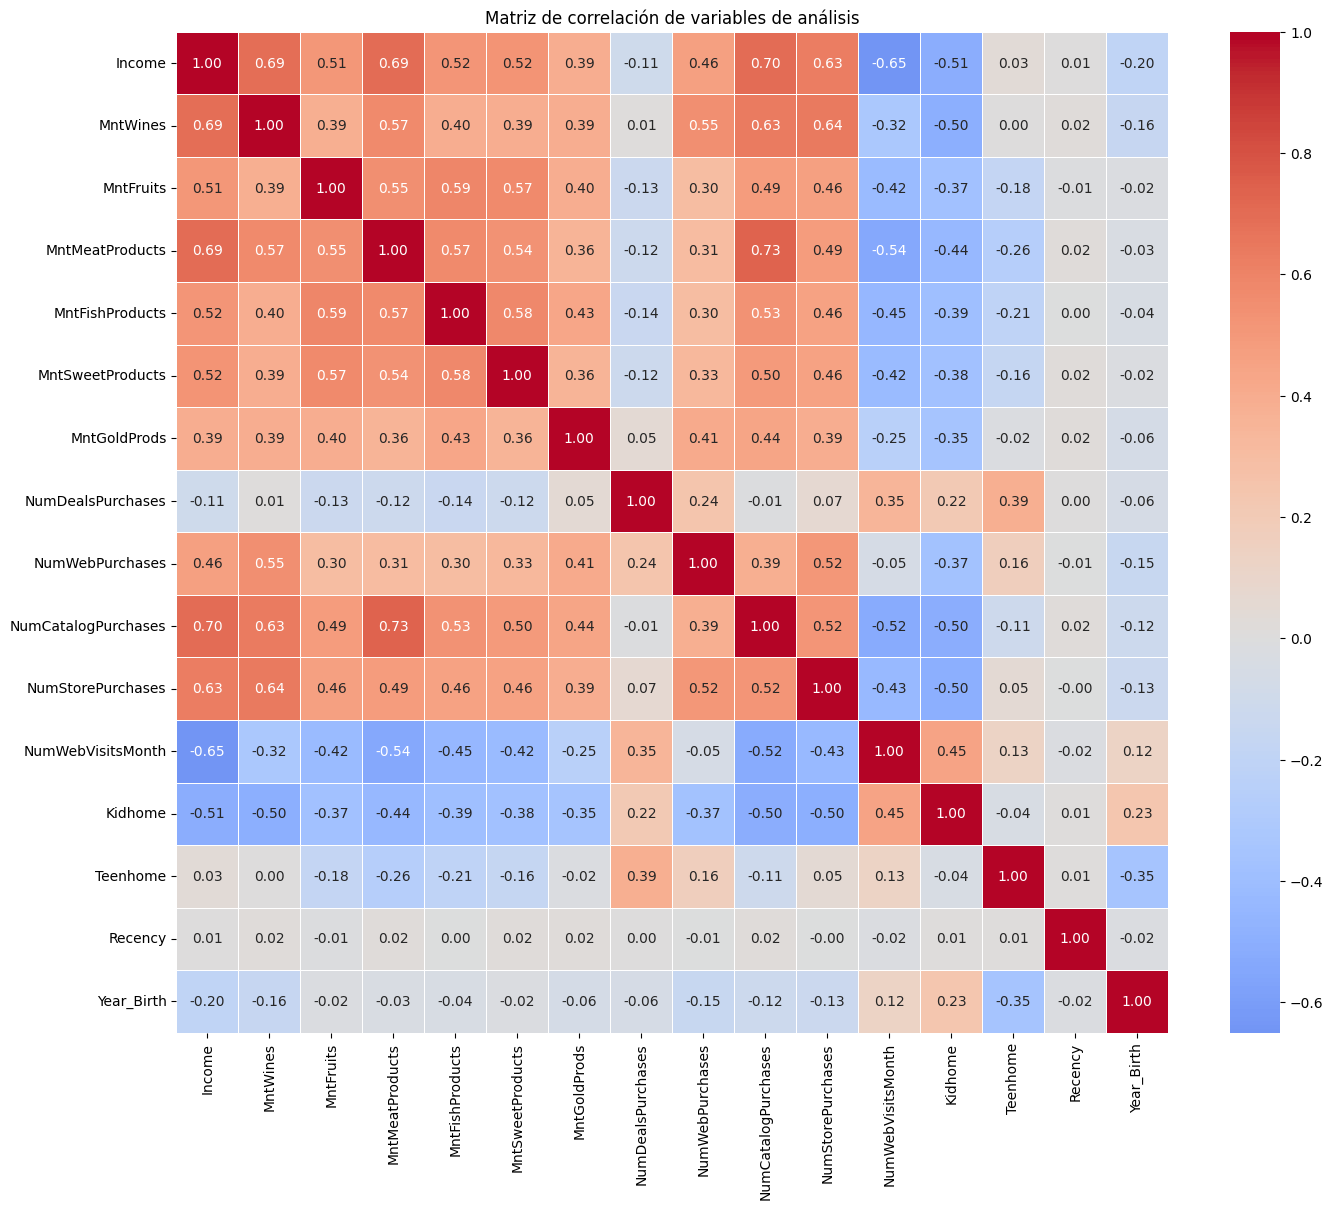

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
variables_analisis = [
    'Income',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth',
    'Kidhome',
    'Teenhome',
    'Recency',
    'Year_Birth'
]

correlacion_analisis = df[variables_analisis].corr()

plt.figure(figsize=(16, 13))

sns.heatmap(
    correlacion_analisis,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Matriz de correlación de variables de análisis')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [29]:
variables_obligatorias = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

correlacion_obligatorias = correlacion_analisis[variables_obligatorias]

correlacion_obligatorias

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Income,0.688269,0.507959,0.692465,0.520351,0.523746,0.389204
MntWines,1.000000,0.386977,0.568752,0.397602,0.390178,0.392588
MntFruits,0.386977,1.000000,0.547796,0.593407,0.571581,0.396443
MntMeatProducts,0.568752,0.547796,1.000000,0.573507,0.535048,0.359328
MntFishProducts,0.397602,0.593407,0.573507,1.000000,0.583804,0.427056
MntSweetProducts,0.390178,0.571581,0.535048,0.583804,1.000000,0.357336
MntGoldProds,0.392588,0.396443,0.359328,0.427056,0.357336,1.000000
NumDealsPurchases,0.009235,-0.134416,-0.121079,-0.143062,-0.121214,0.052161
NumWebPurchases,0.553745,0.302001,0.307013,0.299621,0.333866,0.407005
NumCatalogPurchases,0.634684,0.486229,0.734082,0.532692,0.495054,0.442340


8. Relacion absoluta de cada variable con las 6 variables obligatorias de gasto

In [30]:
relacion_variables = correlacion_analisis[variables_obligatorias].abs().mean(axis=1)

relacion_variables = relacion_variables.sort_values(
    ascending=False
)

relacion_variables

,0
MntMeatProducts,0.597405
MntFishProducts,0.595896
MntFruits,0.582701
MntSweetProducts,0.572991
NumCatalogPurchases,0.554180
Income,0.553666
MntWines,0.522683
MntGoldProds,0.488792
NumStorePurchases,0.481000
Kidhome,0.405174


9. Variables que se van a utilizar para clusterizar teniendo en cuenta la relacion que tiene las variables obligatorias con el resto y  sin perder el bojetivo de nuestro analisis que es el comportamiento de compra y de consumo

In [33]:
variables_clustering = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'Income',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumDealsPurchases',
    'NumWebVisitsMonth'
]

X = df[variables_clustering].copy()

X.head()

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Income,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth
0,635,88,546,172,88,88,58138.0,8,10,4,3,7
1,11,1,6,2,1,6,46344.0,1,1,2,2,5
2,426,49,127,111,21,42,71613.0,8,2,10,1,4
3,11,4,20,10,3,5,26646.0,2,0,4,2,6
4,173,43,118,46,27,15,58293.0,5,3,6,5,5


In [34]:
X.shape

(2215, 12)

10. Escalar variables

Este paso es fundamental porque ya observamos que hay variables como Income que tiene valores mas altos porque esta variable corresponde a los ingresos de los clientes y para segmentar comportamientos de consumo y compra esto es vital

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


array([[ 9.77778869e-01,  1.54897337e+00,  1.68971392e+00,
         2.45393178e+00,  1.48434043e+00,  8.49633270e-01,
         2.86604092e-01,  1.42810276e+00,  2.50407354e+00,
        -5.54499822e-01,  3.52087940e-01,  6.93214637e-01],
       [-8.72375134e-01, -6.37338059e-01, -7.18195603e-01,
        -6.51178432e-01, -6.34080768e-01, -7.33043421e-01,
        -2.61407047e-01, -1.12584572e+00, -5.71253347e-01,
        -1.16983905e+00, -1.67828585e-01, -1.31420390e-01],
       [ 3.58095878e-01,  5.68902727e-01, -1.78645507e-01,
         1.33974518e+00, -1.47087390e-01, -3.82097522e-02,
         9.12723314e-01,  1.42810276e+00, -2.29550359e-01,
         1.29151787e+00, -6.87745110e-01, -5.43737904e-01],
       [-8.72375134e-01, -5.61948009e-01, -6.55768319e-01,
        -5.05055598e-01, -5.85381431e-01, -7.52344357e-01,
        -1.17667951e+00, -7.60995936e-01, -9.12956335e-01,
        -5.54499822e-01, -1.67828585e-01,  2.80897123e-01],
       [-3.92046691e-01,  4.18122629e-01, -2.1877733

11. K-means

K=1 - Inercia: 26579.999999999985
K=2 - Inercia: 16345.192998980829
K=3 - Inercia: 13733.993161845712
K=4 - Inercia: 12735.720928648378
K=5 - Inercia: 11954.946319981447
K=6 - Inercia: 11397.148951937717
K=7 - Inercia: 10903.358379042313
K=8 - Inercia: 10475.842677760882
K=9 - Inercia: 10131.609706348341
K=10 - Inercia: 9705.02093718138


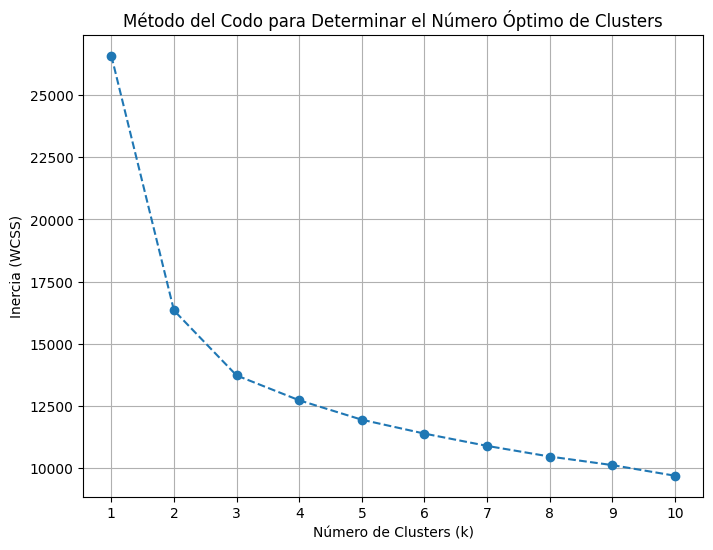

In [41]:
from sklearn.cluster import KMeans
# Método del Codo para encontrar el número óptimo de clusters

inertia = []
K_range = range(1, 11)  # Probaremos de 1 a 10 clusters

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

    print(f"K={k} - Inercia: {kmeans.inertia_}")


# Graficar el método del codo

plt.figure(figsize=(8, 6))

plt.plot(
    K_range,
    inertia,
    marker='o',
    linestyle='--'
)

plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (WCSS)')
plt.title('Método del Codo para Determinar el Número Óptimo de Clusters')

plt.xticks(K_range)
plt.grid(True)

plt.show()

El codo esta aproximadamente en el K=3 poque apartir de ahi se aplana mucho

12. Crear modelo K-means con 3 clusters

In [42]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Entrenar el modelo
kmeans.fit(X_scaled)

# Asignar cada cliente a un cluster
df['Cluster'] = kmeans.labels_

# Ver la cantidad de clientes en cada cluster
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,593
1,1025
2,597


En el cluster 0 quedaron 593 clientes

En el cluster 1 1025 clientes

En el cluster 2 597 clientes

13. Centroides de los clusters

In [45]:
centroides = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=variables_clustering
)

centroides

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Income,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth
0,0.476905,-0.134060,-0.144965,-0.196023,-0.152220,0.292770,0.256675,0.829454,0.101204,0.557884,0.782575,0.246827
1,-0.781516,-0.544541,-0.647168,-0.558961,-0.537989,-0.562084,-0.796252,-0.735012,-0.725936,-0.797934,-0.172901,0.453467
2,0.868089,1.068093,1.255128,1.154399,1.074883,0.674244,1.112143,0.438058,1.145847,0.815841,-0.480475,-1.023739


14. Llevar estos centroides otra vez a los valores normales para analizarlos

In [46]:
centroides_originales = scaler.inverse_transform(kmeans.cluster_centers_)

centroides_originales = pd.DataFrame(
    centroides_originales,
    columns=variables_clustering
)

centroides_originales.round(2)

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Income,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumDealsPurchases,NumWebVisitsMonth
0,466.07,21.03,134.55,26.92,20.79,59.15,57493.88,6.36,2.97,7.62,3.83,5.92
1,41.64,4.69,21.93,7.05,4.95,14.86,34833.37,2.07,0.55,3.21,1.99,6.42
2,598.01,68.86,448.54,100.85,71.18,78.91,75904.81,5.29,6.03,8.45,1.40,2.84


Resultados finales

- Cluster 0= Clientes de consumo medio y alto. Este grupo tiene un nivel de consumo considerable, especialmente en vinos. y tambien tiene una frecuencia alta de compras por pagina web y tienda.

Lo mas relevante de este grupo es que son muy sensibles a las promociones (3.83 compras con descuento)

- Cluster 1= Clientes de bajo consumo. Este es el gurpo mas grande, tiene el menor ingreso promedio y los niveles mas bajos de gasto en todas las categorias, tambien tiene pocas compras.

Lo mas relevante de este grupo es que tienen el mayor numero de visitas en la web (6,42) apesar de que compran poco. En terminos de marketing a estos clientes se les podria llamar los de baja conversion, porque visitan la web, pero no compran, quier decir que no convierten en ventas.

- Cluster 2= Clientes de alto valor. Este grupo tiene ell mayor ingreso promedio (75 904) y tambien tiene los mayores niveles de gastos, con mucha diferencia a comparacion de los otros grupos. Tambien tiene las mayores compras por catalogo y tienda.

Algo muy relevante de este grupo es que tiene el numero mas bajo de visitas a la pagina web pero el comportamiento de compra es alto, es decir que no necesitan visitar tanto la web para comprar

Conclusion

Este modelo de K means me permitio identificar tres sgementos de clientes muy diferenciados segun los niveles de ingresos, gastos y comportamiento de compra.

Algunas recomendaciones que le haria al area de mercadeo basandome en este analisis es enfocarse especialmente en el cluster 2 que son los clientes de mayor ingreso y mayor consumo. A este grupo se les podrian ofrecer productos mas exclusivos y beneficios para fidelizar estos clientes y manetnerlos en el tiempo.

El grupo 1 se debe trabajar para mantener la conversion, ya que este es el grupo mas grande y tiene bajo consumo. Se podrian implementar promociones y campanas digitales que conviertan las visitas que hacen a la pagina web en compras.

Finalmente para el grupo 0 la recomendacion es usar promociones de manera estrategica, ya que este grupo tien un conusmo medio-alto y compra mucho con descuento. Por esto se les puede ofrecer promociones o paquetes para incentivar las compras adicionales.